# Visualización del Desempeño Estudiantil en Exámenes con Superficies 3D y Gráficos de Dispersión (PROC G3D)


## Resumen Ejecutivo

Este cuaderno usa **PROC G3D** para visualizar cómo dos factores de
intervención instructiva moldean conjuntamente los resultados
estudiantiles en un entorno de análisis educativo. Una malla factorial
completa impulsa una **superficie** de respuesta suave de puntajes de
examen predichos sobre las horas de estudio semanales (0 a 20) y el
promedio anterior (0 a 4), y una cohorte sintética de 100 estudiantes se
renderiza como paneles de **dispersión 3D** divididos por nivel de
desempeño.

La superficie ajustada asciende desde un puntaje predicho cercano a 26
con cero horas de estudio hacia un techo cercano a 99, aplanándose cuando
las horas de estudio superan aproximadamente 10 — la cresta de
rendimientos decrecientes que codifica el modelo. Los paneles de
estudiantes confirman el patrón a nivel individual: los 20 estudiantes de
*Honores* (todos con puntaje de 85 o más) se ubican en la esquina de
promedio alto y estudio alto, mientras que los 33 estudiantes en *Riesgo*
se concentran en la región de bajo esfuerzo y bajo promedio. Una vista
filtrada por WHERE de esa esquina aísla a 35 estudiantes para quienes
aumentos modestos en el tiempo de estudio ofrecen las mayores ganancias
marginales.


## Fuentes de Datos

Todos los datos se generan en línea con `call streaminit()` y `rand()` —
sin archivos externos ni acceso a la red.

**`score_grid`** — malla factorial completa que impulsa la superficie de
respuesta (una fila por celda de horas-de-estudio x promedio-anterior, 99
filas).

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `study_hours` | Num | Horas de autoestudio semanales, 0 a 20 de 2 en 2 (eje X) |
| `prior_gpa` | Num | Promedio del período anterior en una escala de 0–4, 0 a 4 de 0.5 en 0.5 (eje Y) |
| `pred_score` | Num | Puntaje de examen final modelado 0–100 a partir de un modelo de respuesta saturante (eje Z) |

**`students`** — cohorte sintética de estudiantes individuales para la
dispersión (100 filas).

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `student_id` | Num | Identificador secuencial del estudiante |
| `study_hours` | Num | Horas de estudio semanales observadas (eje X) |
| `prior_gpa` | Num | Promedio del período anterior observado (eje Y) |
| `exam_score` | Num | Puntaje de examen final observado 0–100 (eje Z) |
| `cohort` | Char | Cohorte de inscripción, `Otoño` o `Primavera` |
| `band` | Char | Nivel de desempeño: `Honores` (≥85), `Aprobado` (65–84), `Riesgo` (<65) |

La malla está deliberadamente dimensionada a 99 celdas para que abarque
todo el rango de 0–20 horas de estudio y 0–4 de promedio mientras se
mantiene dentro del límite de 100 observaciones de este entorno; una
retícula de 11 x 9 mantiene la superficie suave sin truncar ningún eje.


# Visualizando el Desempeño Estudiantil en Exámenes con PROC G3D

Los investigadores educativos a menudo quieren entender cómo dos
factores modificables impulsan conjuntamente un resultado. Aquí
preguntamos: *¿cómo se combinan las horas de estudio semanales y el
promedio anterior de un estudiante para moldear el desempeño en el
examen final?*

Un gráfico bidimensional no puede mostrar una superficie de interacción.
**PROC G3D** dibuja gráficos verdaderamente tridimensionales a partir de
variables en notación `y*x=z`, donde X e Y abarcan el plano horizontal y
Z se eleva verticalmente. Usamos dos de sus capacidades:

- **PLOT** — una *superficie* de respuesta continua sobre una malla
  completa de los dos predictores.
- **SCATTER** — estudiantes individuales graficados como símbolos 3D.
  Dibujamos un panel por nivel de desempeño, cada uno con su propio color
  y forma de marcador, de modo que los tres niveles de resultado sean
  fáciles de comparar.

Todo lo que sigue se ejecuta sobre datos sintéticos generados en línea,
por lo que el cuaderno es completamente autocontenido.


## Paso 1 — Generar la malla de la superficie de respuesta

Un gráfico de superficie de G3D necesita una malla razonablemente
completa: requiere valores Z no faltantes para al menos la mitad de las
celdas X-Y. Garantizamos una malla *completa* anidando dos bucles `DO`
sobre `study_hours` (0 a 20 de 2 en 2) y `prior_gpa` (0 a 4 de 0.5 en
0.5) — una retícula de 11 x 9 de 99 celdas que cubre ambos ejes por
completo.

El puntaje predicho sigue un modelo saturante plausible: los
rendimientos al estudiar disminuyen con horas altas, el promedio
anterior contribuye de forma aproximadamente lineal, y los dos
interactúan (un estudiante fuerte convierte el tiempo de estudio en
puntos de forma más eficiente). Un pequeño ruido reproducible de
`rand('NORMAL')` evita que la superficie luzca perfectamente analítica.
`call streaminit()` fija la semilla para que la malla sea reproducible.


In [1]:
DATOS score_grid;
   LLAMAR streaminit(20260531);
   HACER study_hours = 0 HASTA 20 POR 2;     /* 11 valores: rango completo 0-20 */
      HACER prior_gpa = 0 HASTA 4 POR 0.5;   /* 9 valores  -> 99 celdas de malla */
         /* retorno saturante a las horas de estudio */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* logro anterior y un termino de interaccion */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         SI pred_score > 100 ENTONCES pred_score = 100;
         SI pred_score < 0   ENTONCES pred_score = 0;
         SALIDA;
      END;
   END;
   MANTENER study_hours prior_gpa pred_score;
   ETIQUETA study_hours="Horas de Estudio Semanales" prior_gpa="Promedio Anterior" pred_score="Puntaje Predicho";
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=score_grid n MIN mean MAX maxdec=1;
   VAR study_hours prior_gpa pred_score;
   ETIQUETA study_hours="Horas de Estudio Semanales" prior_gpa="Promedio Anterior" pred_score="Puntaje Predicho";
EJECUTAR;


                                                  The MEANS Procedure

 Variable     Label                             N     Minimum        Mean     Maximum
 ------------------------------------------------------------------------------------
 study_hours  Horas de Estudio Semanales       99         0.0        10.0        20.0
 prior_gpa    Promedio Anterior                99         0.0         2.0         4.0
 pred_score   Puntaje Predicho                 99        25.7        70.0        98.7
 ------------------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Paso 2 — Dibujar la superficie de respuesta base

Con una malla completa en mano, la llamada más simple grafica la
superficie usando los valores predeterminados del procedimiento. La
sintaxis `PLOT y*x=z` asigna `prior_gpa` al eje Y, `study_hours` al eje
X, y el puntaje predicho al eje Z vertical.

Etiquetamos los ejes con una instrucción `LABEL` y fijamos títulos y una
nota al pie con las instrucciones globales `TITLE`/`FOOTNOTE` para que el
gráfico se lea con claridad.


                                    Superficie de Puntaje Predicho del Examen Final                                     
                            Efecto de las Horas de Estudio Semanales y el Promedio Anterior                             

PROC G3D Output
Data: score_grid

Variables: Horas de Estudio Semanales, Promedio Anterior, Puntaje de Examen Predicho

Horas de Estudio Semanales  Promedio Anterior  Puntaje de Examen Predicho
--------------------------  -----------------  --------------------------
                         0                  0               25.7031536911
                         0                0.5               28.9516502743
                         0                  1               32.3400787822
                         0                1.5               36.8265757618
                         0                  2               40.7806886968
                         0                2.5                 42.61364606
                         0                  3


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Superficie de Puntaje Predicho del Examen Final.
NOTE: Option TITLE2 changed to Efecto de las Horas de Estudio Semanales y el Promedio Anterior.
NOTE: Option FOOTNOTE changed to Datos sintéticos de análisis educativo .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


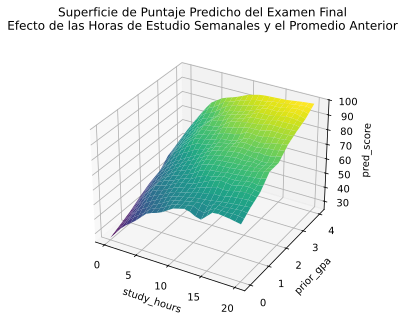

In [2]:
GOPTIONS reset=GLOBAL BORDER;

TÍTULO 'Superficie de Puntaje Predicho del Examen Final';
title2 'Efecto de las Horas de Estudio Semanales y el Promedio Anterior';
footnote j=r 'Datos sintéticos de análisis educativo ';

PROCEDIMIENTO g3d DATOS=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   ETIQUETA study_hours = 'Horas de Estudio Semanales'
         prior_gpa   = 'Promedio Anterior'
         pred_score  = 'Puntaje de Examen Predicho';
EJECUTAR;
QUIT;


## Paso 3 — Refinar la superficie con opciones de vista y de ejes

Algunas opciones hacen que la superficie sea mucho más legible:

- **ROTATE=** y **TILT=** fijan el ángulo de vista (grados alrededor del
  eje Z, e inclinación hacia el espectador).
- **XYTYPE=2** dibuja líneas de superficie paralelas al eje Y,
  enfatizando cómo el puntaje asciende con las horas de estudio.
- **SIDE** agrega una pared lateral para un aspecto sólido y esculpido.
- **GRID** agrega líneas de referencia en las marcas mayores.
- **ZMIN=/ZMAX=** y la familia **ZTICKNUM=** fijan el eje del puntaje al
  rango completo de 0–100 para que la superficie no se exagere
  visualmente, mientras que **XTICKNUM=/YTICKNUM=** controlan las marcas
  del plano del piso.
- **NAME=** y **DESCRIPTION=** etiquetan el gráfico en el catálogo de
  salida.


                              Superficie de Puntaje de Examen Predicho (Vista Estilizada)                               
                                        Rotada, Inclinada, y con Ejes Escalados                                         

PROC G3D Output
Data: score_grid

Variables: Horas de Estudio Semanales, Promedio Anterior, Puntaje de Examen Predicho

Horas de Estudio Semanales  Promedio Anterior  Puntaje de Examen Predicho
--------------------------  -----------------  --------------------------
                         0                  0               25.7031536911
                         0                0.5               28.9516502743
                         0                  1               32.3400787822
                         0                1.5               36.8265757618
                         0                  2               40.7806886968
                         0                2.5                 42.61364606
                         0                  3


NOTE: Option TITLE changed to Superficie de Puntaje de Examen Predicho (Vista Estilizada).
NOTE: Option TITLE2 changed to Rotada, Inclinada, y con Ejes Escalados.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


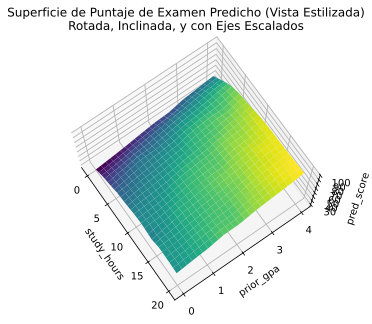

In [3]:
TÍTULO 'Superficie de Puntaje de Examen Predicho (Vista Estilizada)';
title2 'Rotada, Inclinada, y con Ejes Escalados';

PROCEDIMIENTO g3d DATOS=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Superficie de respuesta de puntaje de examen estilizada";
   ETIQUETA study_hours = 'Horas de Estudio Semanales'
         prior_gpa   = 'Promedio Anterior'
         pred_score  = 'Puntaje de Examen Predicho';
EJECUTAR;
QUIT;


## Paso 4 — Comparar la superficie desde varios ángulos de vista

Debido a que una superficie 3D puede ocultar estructura detrás de sus
propios picos, ayuda representar la misma superficie desde más de una
rotación. Aquí emitimos tres pasos de PROC G3D que comparten una
inclinación fija pero avanzan el ángulo **ROTATE=** por 30, 90, y 150
grados, de modo que la cresta pueda inspeccionarse desde el frente, el
lado, y atrás.


                                                Superficie de Respuesta                                                 
                                            ROTATE = 30 con Inclinación Fija                                            

PROC G3D Output
Data: score_grid

Variables: Horas de Estudio Semanales, Promedio Anterior, Puntaje de Examen Predicho

Horas de Estudio Semanales  Promedio Anterior  Puntaje de Examen Predicho
--------------------------  -----------------  --------------------------
                         0                  0               25.7031536911
                         0                0.5               28.9516502743
                         0                  1               32.3400787822
                         0                1.5               36.8265757618
                         0                  2               40.7806886968
                         0                2.5                 42.61364606
                         0                  3


NOTE: Option TITLE changed to Superficie de Respuesta.
NOTE: Option TITLE2 changed to ROTATE = 30 con Inclinación Fija.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Superficie de Respuesta.
NOTE: Option TITLE2 changed to ROTATE = 90 con Inclinación Fija.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Superficie de Respuesta.
NOTE: Option TITLE2 changed to ROTATE = 150 con Inclinación Fija.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


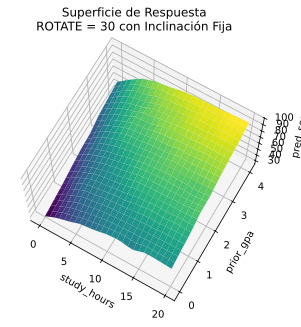

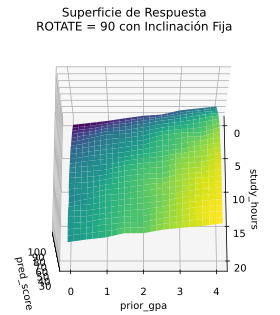

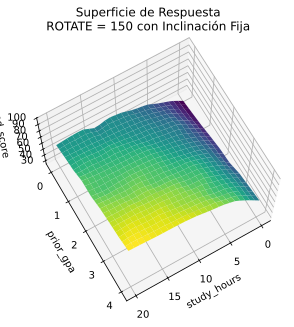

In [4]:
%macro angle(deg);
   TÍTULO 'Superficie de Respuesta';
   title2 "ROTATE = &deg con Inclinación Fija";
   PROCEDIMIENTO g3d DATOS=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      ETIQUETA study_hours = 'Horas de Estudio Semanales'
            prior_gpa   = 'Promedio Anterior'
            pred_score  = 'Puntaje de Examen Predicho';
   EJECUTAR;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);


## Paso 5 — Generar una cohorte sintética de estudiantes

La superficie es un modelo; los estudiantes reales se dispersan a su
alrededor. Ahora simulamos 100 estudiantes individuales extraídos de dos
cohortes de inscripción (`Otoño`, `Primavera`). Cada estudiante tiene
horas de estudio observadas, un promedio anterior, y un puntaje de examen
realizado con ruido generado a partir de la misma lógica de respuesta
más una mayor variación individual.

Luego derivamos un **nivel de desempeño** a partir del puntaje del
examen: `Honores` (85 o más), `Aprobado` (65 a 84), y `Riesgo` (menos de
65). La tabulación cruzada de PROC FREQ a continuación reporta cómo se
distribuyen los niveles entre las dos cohortes. `rand('UNIFORM')` y
`rand('NORMAL')` proveen la aleatoriedad; la semilla mantiene la
reproducibilidad.


                                                Superficie de Respuesta                                                 
                                           ROTATE = 150 con Inclinación Fija                                            

                                                   The FREQ Procedure

                                    Cumulative
Nivel de Desempeño     Frequency    Frequency
-------------------------------------------------
Aprobado                      47           47
Honores                       20           67
Riesgo                        33          100

Table of Cohorte by Nivel de Desempeño

Cohorte   |  Aprobado |   Honores |    Riesgo |      Total
----------+-----------+-----------+-----------+-----------
Otoño     |        20 |         6 |        15 |         41
----------+-----------+-----------+-----------+-----------
Primavera |        27 |        14 |        18 |         59
----------+-----------+-----------+-----------+-----------
Total     


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


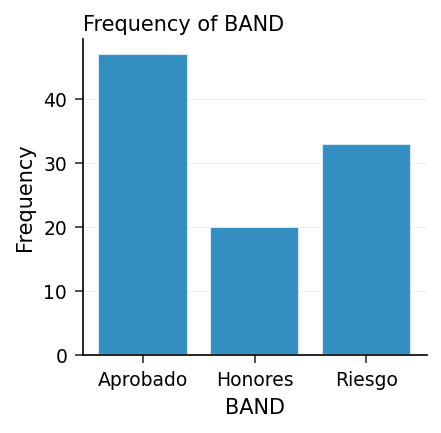

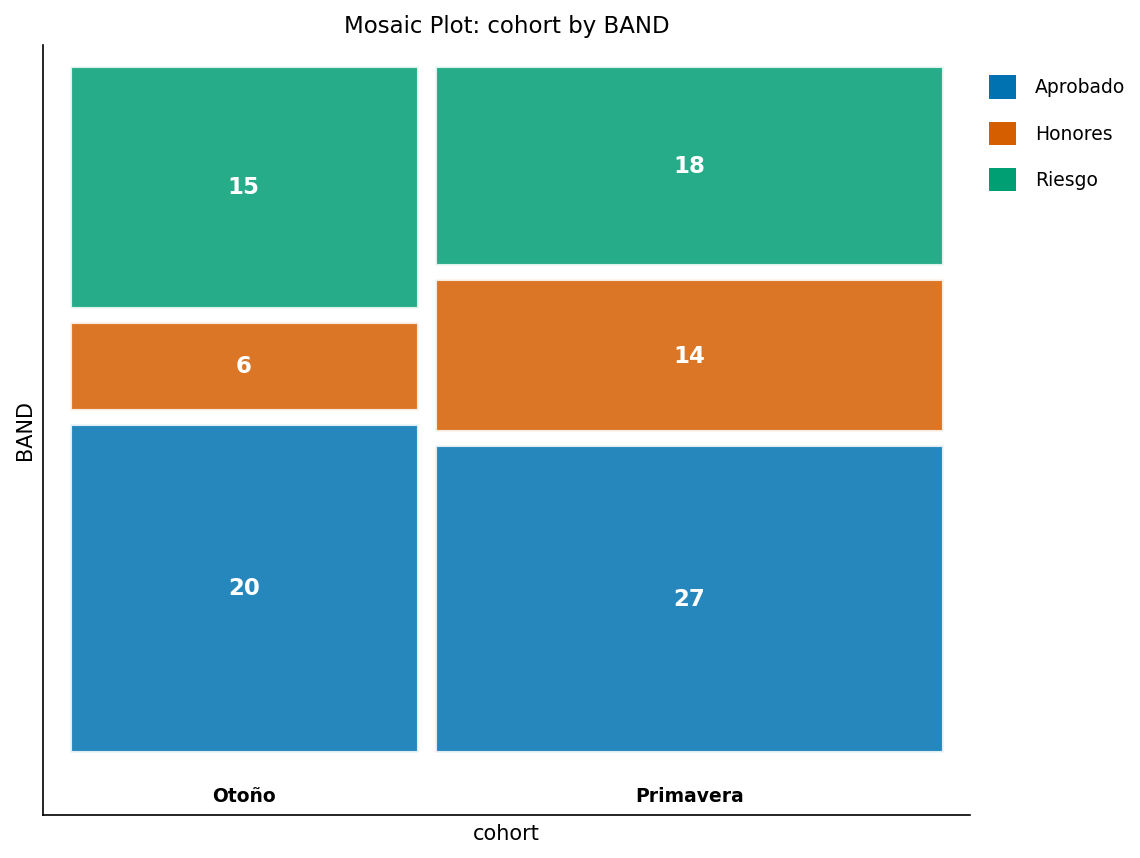

In [5]:
DATOS students;
   LLAMAR streaminit(99001);
   LONGITUD cohort $12 BAND $10;
   HACER student_id = 1 HASTA 100;
      SI rand('UNIFORM') < 0.5 ENTONCES cohort = 'Otoño';
      SINO cohort = 'Primavera';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      SI exam_score > 100 ENTONCES exam_score = 100;
      SI exam_score < 0   ENTONCES exam_score = 0;

      SI exam_score >= 85 ENTONCES BAND = 'Honores';
      SINO SI exam_score >= 65 ENTONCES BAND = 'Aprobado';
      SINO BAND = 'Riesgo';

      SALIDA;
   END;
   MANTENER student_id cohort study_hours prior_gpa exam_score BAND;
   ETIQUETA cohort="Cohorte" BAND="Nivel de Desempeño" study_hours="Horas de Estudio Semanales"
         prior_gpa="Promedio Anterior" exam_score="Puntaje del Examen";
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   ETIQUETA BAND="Nivel de Desempeño" cohort="Cohorte";
EJECUTAR;


## Paso 6 — Graficar estudiantes como paneles de dispersión 3D por nivel de desempeño

La instrucción **SCATTER** ubica a cada estudiante como un símbolo 3D.
Para que los tres niveles de desempeño sean fáciles de leer, dibujamos un
panel por nivel, cada uno filtrado con **WHERE** y con su propio
**COLOR=** y **SHAPE=** literales: diamantes verdes (`SHAPE=diamond`)
para *Honores*, marcadores azules (`SHAPE=club`) para *Aprobado*, y
marcadores rojos (`SHAPE=spade`) para *Riesgo*. **SIZE=** agranda los
marcadores, **GRID** agrega líneas de referencia del piso, **NONEEDLE**
elimina las líneas de caída verticales, y **ZMIN=/ZMAX=** mantienen cada
panel en el mismo eje de puntaje 0–100 para que las tres vistas sean
directamente comparables.

Cada nivel obtiene su propio paso de PROC G3D para que su filtro WHERE
se aplique limpiamente y el estilo del marcador sea inequívoco.


                                                 Estudiantes de Honores                                                 
                                            Puntaje de Examen 85 y Superior                                             

PROC G3D Output
Data: students

Variables: student_id, Cohorte, Horas de Estudio Semanales, Promedio Anterior, Puntaje del Examen Final, Nivel de Desempeño

student_id     Cohorte  Horas de Estudio Semanales  Promedio Anterior  Puntaje del Examen Final   Nivel de Desempeño
----------  ----------  --------------------------  -----------------  ------------------------  -------------------
         2   Primavera               19.2134883194       2.6467742616             90.3663886999              Honores
         5   Primavera               15.5520919174       2.7102003827             94.9419468332              Honores
        10   Primavera               14.2302640951       3.8791496428                       100              Honores
        17   Pr


NOTE: Option FOOTNOTE changed to De una cohorte de 100 estudiantes sintéticos .
NOTE: Option TITLE changed to Estudiantes de Honores.
NOTE: Option TITLE2 changed to Puntaje de Examen 85 y Superior.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Estudiantes Aprobados.
NOTE: Option TITLE2 changed to Puntaje de Examen 65 a 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Estudiantes en Riesgo.
NOTE: Option TITLE2 changed to Puntaje de Examen Menor a 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


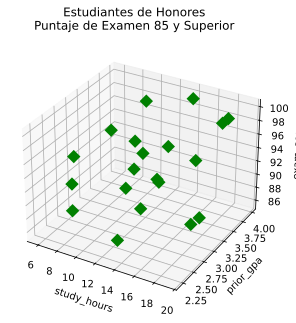

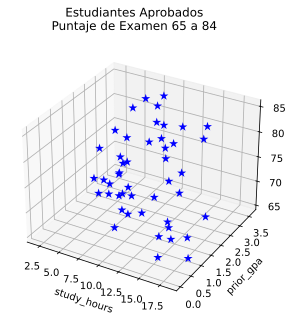

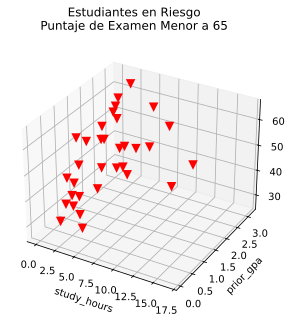

In [6]:
footnote j=r 'De una cohorte de 100 estudiantes sintéticos ';

/* Honores (exam_score >= 85): diamantes verdes */
TÍTULO 'Estudiantes de Honores';
title2 'Puntaje de Examen 85 y Superior';
PROCEDIMIENTO g3d DATOS=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Estudiantes de honores";
   DONDE BAND = 'Honores';
   ETIQUETA study_hours = 'Horas de Estudio Semanales'
         prior_gpa   = 'Promedio Anterior'
         exam_score  = 'Puntaje del Examen Final';
EJECUTAR;
QUIT;

/* Aprobado (65 <= exam_score < 85): tréboles azules */
TÍTULO 'Estudiantes Aprobados';
title2 'Puntaje de Examen 65 a 84';
PROCEDIMIENTO g3d DATOS=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Estudiantes aprobados";
   DONDE BAND = 'Aprobado';
   ETIQUETA study_hours = 'Horas de Estudio Semanales'
         prior_gpa   = 'Promedio Anterior'
         exam_score  = 'Puntaje del Examen Final';
EJECUTAR;
QUIT;

/* En Riesgo (exam_score < 65): picas rojas */
TÍTULO 'Estudiantes en Riesgo';
title2 'Puntaje de Examen Menor a 65';
PROCEDIMIENTO g3d DATOS=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Estudiantes en riesgo";
   DONDE BAND = 'Riesgo';
   ETIQUETA study_hours = 'Horas de Estudio Semanales'
         prior_gpa   = 'Promedio Anterior'
         exam_score  = 'Puntaje del Examen Final';
EJECUTAR;
QUIT;


## Paso 7 — Gráficos de dispersión separados por cohorte de inscripción (grupo BY)

Los líderes de programa a menudo necesitan la misma vista dividida por
cohorte. La instrucción **BY** produce una dispersión por cohorte. G3D
espera que los datos de grupo BY estén ordenados, así que primero
ordenamos con PROC SORT. Cada cohorte obtiene entonces su propia
dispersión 3D etiquetada en un eje de puntaje compartido de 0–100, lo que
facilita comparar las distribuciones de Otoño y Primavera lado a lado.


                                    Resultados de Examen por Cohorte de Inscripción                                     
                                    Una Dispersión 3D por Cohorte (Otoño, Primavera)                                    

PROC G3D Output
Data: students_sorted

Variables: student_id, Cohorte, Horas de Estudio Semanales, Promedio Anterior, Puntaje del Examen Final, Nivel de Desempeño

student_id     Cohorte  Horas de Estudio Semanales  Promedio Anterior  Puntaje del Examen Final   Nivel de Desempeño
----------  ----------  --------------------------  -----------------  ------------------------  -------------------
        52       Otoño               15.2586640362       0.4602308374             55.5186804916               Riesgo
        13       Otoño                5.8493366471       1.8449001873             70.6084324429             Aprobado
        15       Otoño                5.5070892672       1.4478111608             70.0069314398             Aprobado
        


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Resultados de Examen por Cohorte de Inscripción.
NOTE: Option TITLE2 changed to Una Dispersión 3D por Cohorte (Otoño, Primavera).
NOTE: Option FOOTNOTE changed to Un panel por cohorte .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


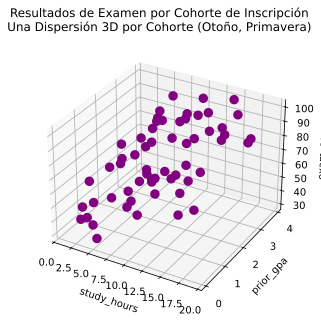

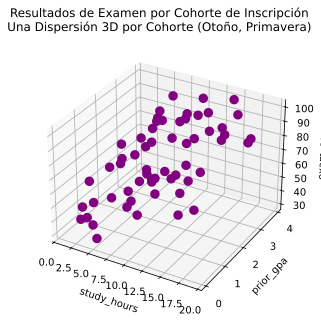

In [7]:
PROCEDIMIENTO ORDENAR DATOS=students out=students_sorted;
   POR cohort;
EJECUTAR;

TÍTULO 'Resultados de Examen por Cohorte de Inscripción';
title2 'Una Dispersión 3D por Cohorte (Otoño, Primavera)';
footnote j=r 'Un panel por cohorte ';

PROCEDIMIENTO g3d DATOS=students_sorted;
   POR cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   ETIQUETA study_hours = 'Horas de Estudio Semanales'
         prior_gpa   = 'Promedio Anterior'
         exam_score  = 'Puntaje del Examen Final';
EJECUTAR;
QUIT;


## Paso 8 — Enfocar en la región en riesgo con WHERE

Para la planificación de intervenciones, la vista más accionable es la
esquina inferior izquierda de la superficie: estudiantes con tiempo de
estudio modesto (8 horas o menos) y promedio anterior más bajo (2.5 o
menos). La instrucción **WHERE** subconjunta la dispersión a esa región
antes de graficar. El listado muestra que esta esquina contiene 35 de los
100 estudiantes — 22 de ellos ya *en Riesgo* — de modo que los asesores
pueden ver exactamente cuáles estudiantes en dificultad están más por
debajo de lo esperado.


                          Foco de Intervención: Estudiantes de Menor Esfuerzo y Menor Promedio                          
                                          study_hours <= 8 y prior_gpa <= 2.5                                           

PROC G3D Output
Data: students

Variables: student_id, Cohorte, Horas de Estudio Semanales, Promedio Anterior, Puntaje del Examen Final, Nivel de Desempeño

student_id     Cohorte  Horas de Estudio Semanales  Promedio Anterior  Puntaje del Examen Final   Nivel de Desempeño
----------  ----------  --------------------------  -----------------  ------------------------  -------------------
         1       Otoño                4.9780700766        1.072086769              59.409228777               Riesgo
         7   Primavera                7.9015823058       1.6623636789             66.9055021729             Aprobado
         9   Primavera                2.5008494545       0.3621033759             48.1183184446               Riesgo
        11   Pr


NOTE: Option TITLE changed to Foco de Intervención: Estudiantes de Menor Esfuerzo y Menor Promedio.
NOTE: Option TITLE2 changed to study_hours <= 8 y prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Las agujas bajan cada marcador al piso de horas-de-estudio x promedio .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


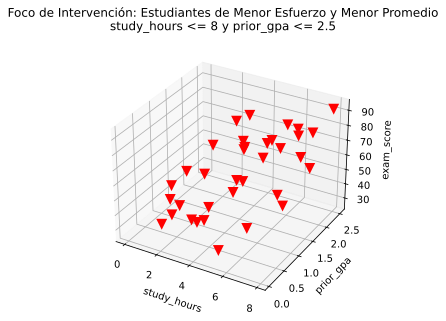

In [8]:
TÍTULO 'Foco de Intervención: Estudiantes de Menor Esfuerzo y Menor Promedio';
title2 'study_hours <= 8 y prior_gpa <= 2.5';
footnote j=r 'Las agujas bajan cada marcador al piso de horas-de-estudio x promedio ';

PROCEDIMIENTO g3d DATOS=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   DONDE study_hours <= 8 AND prior_gpa <= 2.5;
   ETIQUETA study_hours = 'Horas de Estudio Semanales'
         prior_gpa   = 'Promedio Anterior'
         exam_score  = 'Puntaje del Examen Final';
EJECUTAR;
QUIT;


## Interpretando los resultados

La **superficie de respuesta** (Pasos 2–4) muestra una clara cresta
saturante. A través de la malla de 99 celdas, el puntaje predicho va
desde aproximadamente 26 (cero horas de estudio, cero promedio) hasta
aproximadamente 99 (la esquina de horas altas y promedio alto), con una
media de toda la malla cercana a 70. Leyendo a lo largo del eje de horas
de estudio, los puntajes ascienden abruptamente desde 0 hacia
aproximadamente 10 horas y luego se aplanan a medida que las horas
adicionales producen rendimientos decrecientes; leyendo a lo largo del
eje de promedio, el logro anterior desplaza toda la superficie hacia
arriba. El término de interacción hace que el beneficio de las horas de
estudio sea un poco más pronunciado para los estudiantes más fuertes,
razón por la cual la superficie se inclina hacia su esquina lejana en
lugar de ascender como un plano uniforme.

Los **paneles de estudiantes** (Pasos 6–7) confirman que el modelo se
sostiene a nivel individual. La cohorte de 100 se divide en 20 de
*Honores*, 47 de *Aprobado*, y 33 en *Riesgo*. En los paneles por nivel,
los 20 diamantes verdes de *Honores* — todos con puntaje de 85 o más —
se ubican en un promedio anterior de 2.2 o superior y al menos unas 6
horas de estudio semanales, agrupados en la esquina superior derecha del
plano del piso. Los 33 marcadores rojos en *Riesgo* se concentran en la
región de bajo esfuerzo y bajo promedio, precisamente el valle de la
superficie. Dividir por cohorte muestra que las distribuciones de Otoño
(41 estudiantes) y Primavera (59 estudiantes) son ampliamente similares,
lo que sugiere que los resultados están impulsados por los dos factores
más que por el momento de inscripción.

La **vista filtrada por WHERE** (Paso 8) aísla a la población de
intervención: los 35 estudiantes con 8 horas de estudio o menos y un
promedio de 2.5 o menos. Veintidós ya están *en Riesgo* y solo uno
alcanza *Honores*. Dentro de esta esquina, los puntajes realizados aún
ascienden visiblemente con las horas de estudio — un argumento visual
concreto de que aumentos modestos en el tiempo de estudio estructurado
ofrecen las mayores ganancias marginales justo donde más se necesitan.

En conjunto, PROC G3D convierte un modelo de interacción de dos factores
en una imagen intuitiva y lista para la toma de decisiones para un
programa educativo: dónde se encuentra el techo del puntaje, quién está
por debajo de él, y dónde el esfuerzo de asesoría rendirá más frutos.

> **Nota de implementación.** SAS/GRAPH también permite que una sola
> instrucción SCATTER coloree y dé forma a cada marcador a partir de
> variables por observación (`COLOR=<charvar>`, `SHAPE=<charvar>`). Esa
> forma por observación aún no se renderiza en este motor, por lo que
> este cuaderno dibuja un panel de color literal por nivel en su lugar —
> una presentación equivalente y totalmente funcional. La brecha se
> rastrea en la prueba de regresión archivada
> `tests/401000_nb_g3d_scatter_color_variable_unrendered`.
